Imports needed

In [5]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

Load the full Flemish accident database

In [6]:
acc_raw = pl.read_csv(
    'ext/OPENDATA_MAP_2017-2024.txt', separator='|', encoding='utf-8-sig',
    infer_schema_length=20000,
    schema_overrides={'DT_TIME': pl.String,
                      'CD_ROAD_USR_TYPE1': pl.String,
                      'CD_ROAD_USR_TYPE2': pl.String}
)

yearly = (
    acc_raw
    .filter(pl.col('TX_RGN_COLLISION_NL') == 'Vlaams Gewest')
    .group_by('DT_YEAR_COLLISION')
    .agg([
        pl.len().alias('total_accidents'),
        ((pl.col('TX_ROAD_USR_TYPE1_NL') == 'Fiets') |
         (pl.col('TX_ROAD_USR_TYPE2_NL') == 'Fiets')).sum().alias('cyclist_accidents'),
    ])
    .sort('DT_YEAR_COLLISION')
    .rename({'DT_YEAR_COLLISION': 'year'})
    .with_columns(
        (pl.col('cyclist_accidents') / pl.col('total_accidents') * 100).alias('pct_cyclist')
    )
    .to_pandas()
)

yearly

,year,total_accidents,cyclist_accidents,pct_cyclist
0,2017,23239,6784,29.192306
1,2018,23711,7266,30.644005
2,2019,23078,7358,31.883179
3,2020,18663,6697,35.883834
4,2021,21220,7321,34.500471
5,2022,23380,8481,36.274594
6,2023,22872,8075,35.305177
7,2024,22185,7701,34.712644


Cyclist accidents in Flanders rose from 6,784 in 2017 to a peak of 8,481 in 2022
Total road accidents fell by 4.5% over the same period
Cyclists now account for 35% of all accidents, up from 29% in 2017
On first sight this looks alarming -> but raw counts are the wrong thing to measure

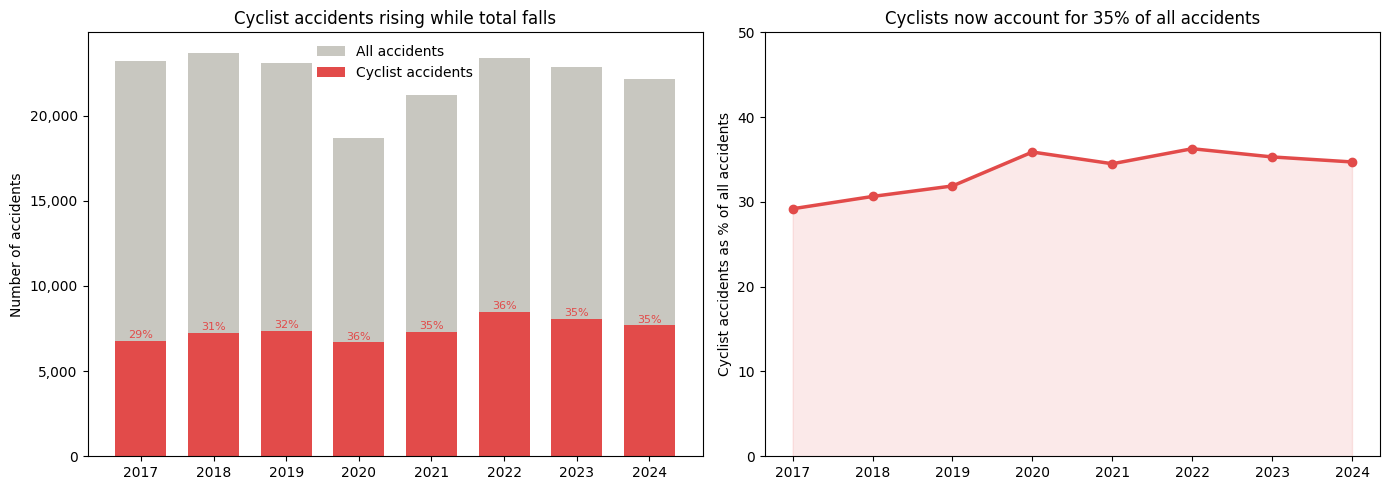

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(yearly['year'], yearly['total_accidents'],
       color='#C8C7C0', label='All accidents', width=0.7)
ax.bar(yearly['year'], yearly['cyclist_accidents'],
       color='#E24B4A', label='Cyclist accidents', width=0.7)
ax.set_ylabel('Number of accidents')
ax.set_title('Cyclist accidents rising while total falls')
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for _, row in yearly.iterrows():
    ax.text(row['year'], row['cyclist_accidents'] + 150,
            f"{row['pct_cyclist']:.0f}%", ha='center', fontsize=8, color='#E24B4A')

ax2 = axes[1]
ax2.plot(yearly['year'], yearly['pct_cyclist'],
         color='#E24B4A', linewidth=2.5, marker='o', markersize=6)
ax2.fill_between(yearly['year'], yearly['pct_cyclist'], alpha=0.12, color='#E24B4A')
ax2.set_ylim(0, 50)
ax2.set_ylabel('Cyclist accidents as % of all accidents')
ax2.set_title('Cyclists now account for 35% of all accidents')

plt.tight_layout()
plt.show()

More cyclists means more exposure -> a 15% rise in accidents alongside growing cycling is not evidence of more danger
To know whether infrastructure is getting safer or more dangerous, we need to control for cycling volume
The WVS sensor network (142 sensors, 68 municipalities) gives us partial data on this

Sensor installation caveat
102 of 142 sensors were installed during 2022, most mid-year
Comparing 2021 vs 2024 aggregate flow mixes sensor installation with real cycling growth
Solution: compare each sensor only to its own readings in its previous full calendar year

In [8]:
sites = pd.read_csv('sites_fin.csv')
site_dates = sites[['site_id', 'gemeente', 'datum_van']].drop_duplicates(subset='site_id')
site_dates['datum_van']       = pd.to_datetime(site_dates['datum_van'])
site_dates['install_month']   = site_dates['datum_van'].dt.month
site_dates['install_year']    = site_dates['datum_van'].dt.year
site_dates['first_full_year'] = np.where(
    site_dates['install_month'] <= 1,
    site_dates['install_year'],
    site_dates['install_year'] + 1
)

sensor_raw = pl.read_csv(
    'counts_fin.csv',
    columns=['site_id', 'hourly_count', 'year'],
    schema_overrides={'site_id': pl.Int64, 'hourly_count': pl.Float64, 'year': pl.Int64}
)

sensor_yearly = (
    sensor_raw
    .group_by(['site_id', 'year'])
    .agg([pl.col('hourly_count').sum().alias('annual_flow'),
          pl.col('hourly_count').count().alias('n_hours')])
    .to_pandas()
    .merge(site_dates[['site_id', 'gemeente', 'first_full_year']], on='site_id', how='left')
)

sensor_yearly = sensor_yearly[
    (sensor_yearly['year'] >= sensor_yearly['first_full_year']) &
    (sensor_yearly['n_hours'] >= 4000) &
    (sensor_yearly['annual_flow'] > 0)
]

sensor_yearly = sensor_yearly.sort_values(['site_id', 'year'])
sensor_yearly['prev_flow'] = sensor_yearly.groupby('site_id')['annual_flow'].shift(1)
sensor_yearly['yoy_growth'] = (
    (sensor_yearly['annual_flow'] - sensor_yearly['prev_flow']) / sensor_yearly['prev_flow']
)
yoy = sensor_yearly.dropna(subset=['yoy_growth'])

print("Cycling volume change per sensor (each sensor vs its own previous full year):")
for year in sorted(yoy[yoy['year'] <= 2024]['year'].unique()):
    sub = yoy[yoy['year'] == year]
    print(f"  {int(year-1)}->{int(year)} ({len(sub)} sensors):  "
          f"median {sub['yoy_growth'].median():+.1%}")

print(f"\nOverall median cycling growth: {yoy[yoy['year']<=2024]['yoy_growth'].median():+.1%} per year")

Cycling volume change per sensor (each sensor vs its own previous full year):
  2021->2022 (24 sensors):  median +21.8%
  2022->2023 (26 sensors):  median +5.3%
  2023->2024 (125 sensors):  median +3.8%

Overall median cycling growth: +5.4% per year


Even controlling for cycling growth, the picture varies enormously by municipality
The per-capita accident rate (accidents per 10,000 residents) increased in 73% of municipalities
But this still uses population as proxy for cycling exposure -> not ideal, but it covers all 295 municipalities

In [9]:
pop_raw = pl.read_csv(
    'ext/TF_SOC_POP_STRUCT_2024.txt', separator='|', encoding='utf-8-sig',
    infer_schema_length=10000, ignore_errors=True
)
pop_mun = (
    pop_raw.filter(pl.col('TX_RGN_DESCR_NL').str.contains('Vlaams'))
    .group_by('TX_DESCR_NL')
    .agg(pl.col('MS_POPULATION').sum().alias('total_pop'))
    .rename({'TX_DESCR_NL': 'gemeente'})
)

cyclist_mun = (
    acc_raw
    .filter(
        (pl.col('TX_RGN_COLLISION_NL') == 'Vlaams Gewest') &
        (pl.col('DT_YEAR_COLLISION').is_between(2017, 2024)) &
        ((pl.col('TX_ROAD_USR_TYPE1_NL') == 'Fiets') |
         (pl.col('TX_ROAD_USR_TYPE2_NL') == 'Fiets'))
    )
    .group_by(['TX_MUNTY_COLLISION_NL', 'DT_YEAR_COLLISION'])
    .agg(pl.len().alias('cyclist_accidents'))
    .rename({'TX_MUNTY_COLLISION_NL': 'gemeente', 'DT_YEAR_COLLISION': 'year'})
    .join(pop_mun, on='gemeente', how='left')
    .with_columns(
        (pl.col('cyclist_accidents') / pl.col('total_pop') * 10000).alias('rate_10k')
    )
    .to_pandas()
)

trends = []
for mun, grp in cyclist_mun.dropna(subset=['rate_10k']).groupby('gemeente'):
    if len(grp) >= 5 and (grp['cyclist_accidents'] > 0).sum() >= 5:
        early  = grp[grp['year'].isin([2017, 2018, 2019])]['rate_10k'].mean()
        recent = grp[grp['year'].isin([2022, 2023, 2024])]['rate_10k'].mean()
        pct    = (recent - early) / early * 100 if early > 0 else 0
        trends.append({'gemeente': mun, 'pct_change': pct,
                       'total_pop': grp['total_pop'].iloc[0]})

trends_df = pd.DataFrame(trends).sort_values('pct_change')
n_imp = (trends_df['pct_change'] < 0).sum()
n_wor = (trends_df['pct_change'] >= 0).sum()

print(f"Improving (<0%): {n_imp} / {len(trends_df)}")
print(f"Worsening (>0%): {n_wor} / {len(trends_df)}")
print(f"Median change: {trends_df['pct_change'].median():.1f}%")

Improving (<0%): 81 / 295
Worsening (>0%): 214 / 295
Median change: 17.3%


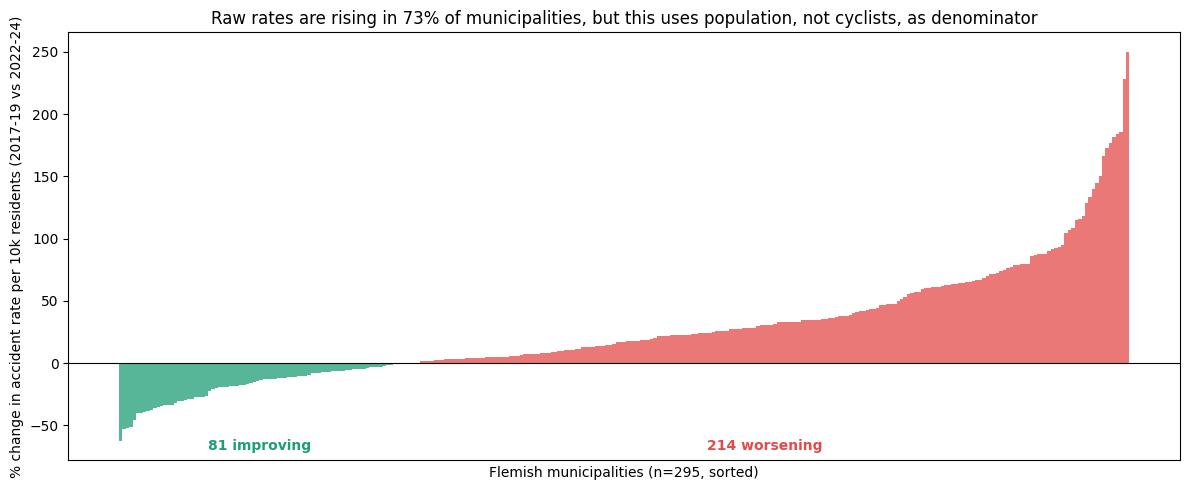

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#1D9E75' if x < 0 else '#E24B4A' for x in trends_df['pct_change']]
ax.bar(range(len(trends_df)), trends_df['pct_change'], color=colors, width=1.0, alpha=0.75)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks([])
ax.set_ylabel('% change in accident rate per 10k residents (2017-19 vs 2022-24)')
ax.set_xlabel(f'Flemish municipalities (n={len(trends_df)}, sorted)')
ax.set_title('Raw rates are rising in 73% of municipalities, but this uses population, not cyclists, as denominator')

ax.annotate(f'{n_imp} improving', xy=(n_imp/2, -70),
            fontsize=10, color='#1D9E75', fontweight='bold', ha='center')
ax.annotate(f'{n_wor} worsening', xy=(n_imp + n_wor/2, -70),
            fontsize=10, color='#E24B4A', fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

Why we can't build a clean per-cyclist metric?
The sensor network covers only 68 of 285 Flemish municipalities and sits on N and R roads (biased sample).
Only 283 accidents fall within 250m of a sensor over 5 years -> too sparse to model locally.
Sensor flow sums across multiple sensors in the same municipality -> a cyclist passing 5 sensors counts 5 times.
There is no clean cycling volume denominator for cross-municipality comparison.

What we CAN say with sensor data: the overall direction of travel.
Cycling volumes are growing at roughly 4-5% per year at sensor locations.
This means the per-cyclist rate is declining even where raw counts are rising.
But the variation between municipalities is large and cannot be fully explained by available data.

This raises two questions that require a model:

1. Which municipalities will have the most accidents? -> resource allocation, where to focus attention
2. Which municipalities have more accidents than their demographics and history predict? -> where something is genuinely going wrong (or right) that the data cannot explain

The sensor data gives us the trend story.
The accident database gives us the scale and distribution.
The model connects both: it can predict total accidents and its residuals show the genuine outliers.

That is the structure of the rest of the analysis.